In [4]:
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv


load_dotenv()

user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
dbname = os.getenv('DB_NAME')

engine = create_engine(f"postgresql://{user}:{password}@{host}:{port}/{dbname}")

In [12]:
import pandas as pd

dim_indicators = pd.read_sql("SELECT * FROM dim_indicators", engine)
fact_macro_observations = pd.read_sql("SELECT * FROM fact_macro_observations", engine)


In [13]:
wide = fact_macro_observations.pivot(index='obs_date', columns='indicator_code', values='value')

In [14]:
wide.tail()

indicator_code,BAA10Y,CFNAI,CPIAUCSL,GDPC1,HOUST,ICSA,INDPRO,NFCI,PAYEMS,PERMIT,SAHMREALTIME,T10Y2Y,T10Y3M,UMCSENT,UNRATE,USREC
obs_date,,,,,,,,,,,,,,,,
2026-07-17,1.59,NaN,NaN,NaN,NaN,NaN,NaN,-0.552,NaN,NaN,NaN,0.37,0.70,NaN,NaN,NaN
2026-07-18,NaN,NaN,NaN,NaN,NaN,187000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-20,1.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.39,0.74,NaN,NaN,NaN
2026-07-21,1.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.37,0.76,NaN,NaN,NaN
2026-07-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.36,0.78,NaN,NaN,NaN


In [18]:
wide.index = pd.to_datetime(wide.index)

In [19]:
wide.index.dtype

dtype('<M8[s]')

In [20]:
monthly = wide.resample('ME').last()
monthly.dropna().shape

(160, 16)

In [22]:
print(monthly.dropna().index.min())
print(monthly.dropna().index.max())

1986-01-31 00:00:00
2026-01-31 00:00:00


In [23]:
wide.notna().sum().sort_values()

indicator_code
GDPC1             317
UMCSENT           673
CFNAI             712
PERMIT            798
SAHMREALTIME      798
HOUST             810
UNRATE            941
CPIAUCSL          953
PAYEMS           1050
INDPRO           1290
USREC            2059
NFCI             2898
ICSA             3107
BAA10Y          10137
T10Y3M          11140
T10Y2Y          12531
dtype: int64

In [24]:
monthly.isna().sum()

indicator_code
BAA10Y          1573
CFNAI           1348
CPIAUCSL        1107
GDPC1           1743
HOUST           1250
ICSA            1345
INDPRO           770
NFCI            1393
PAYEMS          1010
PERMIT          1262
SAHMREALTIME    1262
T10Y2Y          1458
T10Y3M          1525
UMCSENT         1387
UNRATE          1119
USREC              1
dtype: int64

In [25]:
monthly = wide.resample('ME').last().ffill()

In [26]:
monthly_1990 = monthly.loc['1990':]
monthly_1990.dropna().shape

(439, 16)

In [27]:
monthly_1990.index.min(), monthly_1990.index.max()

(Timestamp('1990-01-31 00:00:00'), Timestamp('2026-07-31 00:00:00'))

In [28]:
sahm_binary = (monthly_1990['SAHMREALTIME'] >= 0.5).astype(int)

In [29]:
print(sahm_binary.sum())
print(sahm_binary.value_counts())

83
SAHMREALTIME
0    356
1     83
Name: count, dtype: int64


<Axes: xlabel='obs_date'>

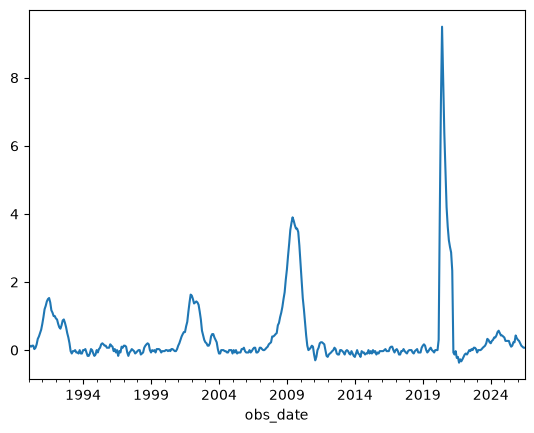

In [33]:
import matplotlib.pyplot as plt
monthly_1990['SAHMREALTIME'].plot()

In [36]:
h = 6

target_h6 = (
    sahm_binary[::-1]
    .rolling(window=6, min_periods=1)
    .max()[::-1]
    .shift(-1)
)
target_h6

obs_date
1990-01-31    0.0
1990-02-28    0.0
1990-03-31    0.0
1990-04-30    0.0
1990-05-31    1.0
             ... 
2026-03-31    0.0
2026-04-30    0.0
2026-05-31    0.0
2026-06-30    0.0
2026-07-31    NaN
Freq: ME, Name: SAHMREALTIME, Length: 439, dtype: float64

In [37]:
target_h6.loc['2019-09-30']

np.float64(0.0)

In [38]:
target_h6.tail(10)

obs_date
2025-10-31    0.0
2025-11-30    0.0
2025-12-31    0.0
2026-01-31    0.0
2026-02-28    0.0
2026-03-31    0.0
2026-04-30    0.0
2026-05-31    0.0
2026-06-30    0.0
2026-07-31    NaN
Freq: ME, Name: SAHMREALTIME, dtype: float64

In [39]:
sahm_binary.loc['2020-01':'2020-06']

obs_date
2020-01-31    0
2020-02-29    0
2020-03-31    0
2020-04-30    1
2020-05-31    1
2020-06-30    1
Freq: ME, Name: SAHMREALTIME, dtype: int64

In [42]:
target_h6 = (
    sahm_binary[::-1]
    .rolling(window=6, min_periods=6)
    .max()[::-1]
    .shift(-1)
)

target_h6.tail(10)

obs_date
2025-10-31    0.0
2025-11-30    0.0
2025-12-31    0.0
2026-01-31    0.0
2026-02-28    NaN
2026-03-31    NaN
2026-04-30    NaN
2026-05-31    NaN
2026-06-30    NaN
2026-07-31    NaN
Freq: ME, Name: SAHMREALTIME, dtype: float64

In [43]:
def make_window_target(binary_series, h):
    return (
        binary_series[::-1]
        .rolling(window=h, min_periods=h)
        .max()[::-1]
        .shift(-1)
    )

target_h3 = make_window_target(sahm_binary, 3)
target_h6 = make_window_target(sahm_binary, 6)
target_h12 = make_window_target(sahm_binary, 12)

In [46]:
exclude = ['UNRATE', 'SAHMREALTIME', 'USREC']
feature_candidates = [col for col in monthly_1990.columns if col not in exclude]
feature_candidates

['BAA10Y',
 'CFNAI',
 'CPIAUCSL',
 'GDPC1',
 'HOUST',
 'ICSA',
 'INDPRO',
 'NFCI',
 'PAYEMS',
 'PERMIT',
 'T10Y2Y',
 'T10Y3M',
 'UMCSENT']

In [48]:
targets = {
    3: target_h3,
    6: target_h6,
    12: target_h12
}

for indicator in feature_candidates:
    for h, target_series in targets.items():

        combined = pd.concat(
            [monthly_1990[indicator], target_series],
            axis=1,
            keys=['feature', 'target']
        ).dropna()

        X = combined[['feature']]
        y = combined['target']


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

model = LogisticRegression(class_weight='balanced')

scores = cross_val_score(
    model,
    X,
    y,
    cv=tscv,
    scoring='average_precision'
)

scores.mean(), scores.std()

(np.float64(0.38318544336159166), np.float64(0.22866424456946716))

In [49]:
scores

array([0.60288697, 0.26788251, 0.67897578, 0.05599722, 0.31018473])

In [50]:
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    print(f"fold {i}: train positives = {y_train.sum()}/{len(y_train)}, test positives = {y_test.sum()}/{len(y_test)}")

fold 0: train positives = 34.0/72, test positives = 18.0/71
fold 1: train positives = 52.0/143, test positives = 17.0/71
fold 2: train positives = 69.0/214, test positives = 30.0/71
fold 3: train positives = 99.0/285, test positives = 5.0/71
fold 4: train positives = 104.0/356, test positives = 32.0/71


In [52]:
splits = list(tscv.split(X))
train_idx, test_idx = splits[3]
X.index[test_idx].min(), X.index[test_idx].max()

(Timestamp('2013-10-31 00:00:00'), Timestamp('2019-08-31 00:00:00'))

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

results = []

for indicator in feature_candidates:
    for h, target_series in targets.items():

        combined = pd.concat(
            [monthly_1990[indicator], target_series],
            axis=1, keys=['feature', 'target']
        ).dropna()

        X = combined[['feature']]
        y = combined['target']

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(class_weight='balanced'))
        ])

        scores = cross_val_score(pipe, X, y, cv=tscv, scoring='average_precision')

        results.append({
            'indicator': indicator,
            'horizon': h,
            'mean_pr_auc': scores.mean(),
            'std_pr_auc': scores.std(),
            'min_pr_auc': scores.min()
        })

results_df = pd.DataFrame(results).sort_values('mean_pr_auc', ascending=False)
results_df

,indicator,horizon,mean_pr_auc,std_pr_auc,min_pr_auc
15,ICSA,3,0.703929,0.264643,0.281318
0,BAA10Y,3,0.627474,0.170741,0.376045
16,ICSA,6,0.604273,0.334996,0.045475
1,BAA10Y,6,0.573345,0.309831,0.044254
3,CFNAI,3,0.551912,0.191242,0.222211
5,CFNAI,12,0.548419,0.241106,0.207792
2,BAA10Y,12,0.546620,0.287627,0.064961
4,CFNAI,6,0.540177,0.244865,0.263130
17,ICSA,12,0.539550,0.287661,0.046999
18,INDPRO,3,0.538555,0.262355,0.154941


In [55]:
results_df['stability_gap'] = results_df['mean_pr_auc'] - results_df['min_pr_auc']
results_df.sort_values('stability_gap')  # по возрастанию — самые стабильные наверху

,indicator,horizon,mean_pr_auc,std_pr_auc,min_pr_auc,stability_gap
12,HOUST,3,0.350795,0.186969,0.117045,0.233751
0,BAA10Y,3,0.627474,0.170741,0.376045,0.251429
24,PAYEMS,3,0.386328,0.254914,0.127348,0.258980
27,PERMIT,3,0.335703,0.214916,0.058954,0.276749
4,CFNAI,6,0.540177,0.244865,0.263130,0.277047
26,PAYEMS,12,0.333946,0.244696,0.043076,0.290869
25,PAYEMS,6,0.329469,0.265997,0.035218,0.294250
28,PERMIT,6,0.347423,0.217393,0.035326,0.312096
13,HOUST,6,0.352286,0.215417,0.035537,0.316749
32,T10Y2Y,12,0.363301,0.206062,0.044151,0.319151


In [57]:
import os
os.makedirs('../data/processed', exist_ok=True)
results_df.to_csv('../data/processed/indicator_screening_results.csv', index=False)